For Figure 5 D ConvRNN results

In [1]:
# imports 
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, shapiro, levene, ttest_rel, sem, ttest_1samp
import matplotlib.pyplot as plt

from functions import convert_to_deg

In [2]:
# load the ground truth center positions in pixel space 
human_im_size = 268.51895786308
gt_im_size = 256
df = pd.read_csv('data/mae_s5_coordinates.csv') # position data
xpos = np.squeeze(df['center_x'].values.reshape(-1,1))*(human_im_size/gt_im_size) # convert to the dimensions of the image that the humans made estimates on
xpos = convert_to_deg(xpos,human_im_size)
ypos = np.squeeze(df['center_y'].values.reshape(-1,1))*(human_im_size/gt_im_size)
ypos = convert_to_deg(ypos,human_im_size)

In [28]:
# load the predictions - to recreate these, run fig5_convrnn.sh
s5_xpos = np.load('data/convrnn_predictions/convrnn_s5_xpos_preds_ecc.npy')
s5_ypos = np.load('data/convrnn_predictions/convrnn_s5_ypos_preds_ecc.npy')

s3_xpos = np.load('data/convrnn_predictions/convrnn_s3_xpos_preds_ecc.npy')
s3_ypos = np.load('data/convrnn_predictions/convrnn_s3_ypos_preds_ecc.npy')

s4_xpos = np.load('data/convrnn_predictions/convrnn_s4_xpos_preds_ecc.npy')
s4_ypos = np.load('data/convrnn_predictions/convrnn_s4_ypos_preds_ecc.npy')

In [29]:
# define for plotting lines 
xpos_range = np.linspace(min(xpos),max(xpos))
ypos_range = np.linspace(min(ypos),max(ypos))

In [30]:
# define a function to run the correlation every 10 reps and plot the curve of correlations 
# then the function takes the average correlation and plots the predictions
def gt_corrs(preds_x, preds_y, gt_x, gt_y, n_reps=100, interval=10):
   
    # get the correlations for each rep separately
    xcorr_raw = np.empty(n_reps)
    ycorr_raw = np.empty(n_reps)
    for p in range(n_reps):
        xcorr_temp = pearsonr(gt_x, preds_x[:,p])[0]
        ycorr_temp = pearsonr(gt_y, preds_y[:,p])[0]
        xcorr_raw[p] = xcorr_temp
        ycorr_raw[p] = ycorr_temp
    
    # check that the number of repetitions is divisible by the interval of correlation 
    if preds_x.shape[1] % interval != 0 or preds_y.shape[1] % interval != 0:
        raise ValueError(f'The number of repetitions for x_preds ({preds_x.shape[1]}) or y_preds ({preds_y.shape[1]}) is not divisible by {interval}')

    # get the average correlation across a number of reps
    checkpoint_reps = range(interval,n_reps+interval,interval)
    xcorrs = np.empty(len(checkpoint_reps))
    ycorrs = np.empty(len(checkpoint_reps))
    xstds = np.empty(len(checkpoint_reps))
    ystds = np.empty(len(checkpoint_reps))
    for i in range(len(checkpoint_reps)):
        checkpoint_rep = checkpoint_reps[i]
        xcorrs[i] = np.nanmean(xcorr_raw[:checkpoint_rep])
        ycorrs[i] = np.nanmean(ycorr_raw[:checkpoint_rep])
        xstds[i] = np.nanstd(xcorr_raw[:checkpoint_rep])
        ystds[i] = np.nanstd(ycorr_raw[:checkpoint_rep])
    
    # get the preds for the final correlation
    xfinal_preds = np.nanmean(preds_x,axis=1)
    yfinal_preds = np.nanmean(preds_y,axis=1)
    xfinal_preds_std = np.nanstd(preds_x,axis=1)
    yfinal_preds_std = np.nanstd(preds_y,axis=1)

    # print the best correlation standard deviation for x and y
    print(f'Final x correlation across all 100 reps: r = {np.nanmean(xcorr_raw)} +/- {np.nanstd(xcorr_raw)}')
    print(f'Final y correlation: across all 100 reps: r = {np.nanmean(ycorr_raw)} +/- {np.nanstd(ycorr_raw)}')
    
    # plot the correlation across the number of reps and the best correlation for both x and y
    fig, axs = plt.subplots(nrows=2,ncols=2,sharex='row',sharey='row')
    current_size = fig.get_size_inches() 
    fig.set_size_inches(current_size[0] * 2, current_size[1] * 2.5)

    axs[0,0].errorbar(checkpoint_reps,xcorrs,yerr=xstds,fmt='o', color='darkslateblue')
    axs[0,0].set(title='Pearson r x-position predictions and ground truth across reps', xlabel='Number of Reps', ylabel='Pearson r')

    axs[0,1].errorbar(checkpoint_reps,ycorrs,yerr=ystds,fmt='o', color='lightsteelblue')
    axs[0,1].set(title='Pearson r y-position predictions and ground truth across reps', xlabel='Number of Reps')

    axs[1,0].errorbar(xfinal_preds,gt_x,xerr=xfinal_preds_std,fmt='o', color='darkslateblue')
    axs[1,0].set(title='x-position predictions vs ground truth', ylabel='ground truth', xlabel='predictions')
    axs[1,0].plot(ypos_range,ypos_range,color='grey',linestyle='--')

    axs[1,1].errorbar(yfinal_preds,gt_y,xerr=yfinal_preds_std,fmt='o', color='lightsteelblue')
    axs[1,1].set(title='y-position predictions vs ground truth', xlabel='predictions')
    axs[1,1].plot(ypos_range,ypos_range,color='grey',linestyle='--')

    for m in range(2):
        for n in range(2):
            axs[m,n].spines['top'].set_visible(False)
            axs[m,n].spines['right'].set_visible(False)
            # axs[m,n].label_outer()
            x0, x1 = axs[m,n].get_xlim()
            y0, y1 = axs[m,n].get_ylim()
            axs[m,n].set_aspect(abs(x1 - x0) / abs(y1 - y0))
    
    return [np.nanmean(xcorr_raw), np.nanstd(xcorr_raw), np.nanmean(ycorr_raw), np.nanstd(ycorr_raw)]

Final x correlation across all 100 reps: r = 0.4828859197403918 +/- 0.0709236994650488
Final y correlation: across all 100 reps: r = 0.6910025995280519 +/- 0.06363795204513523


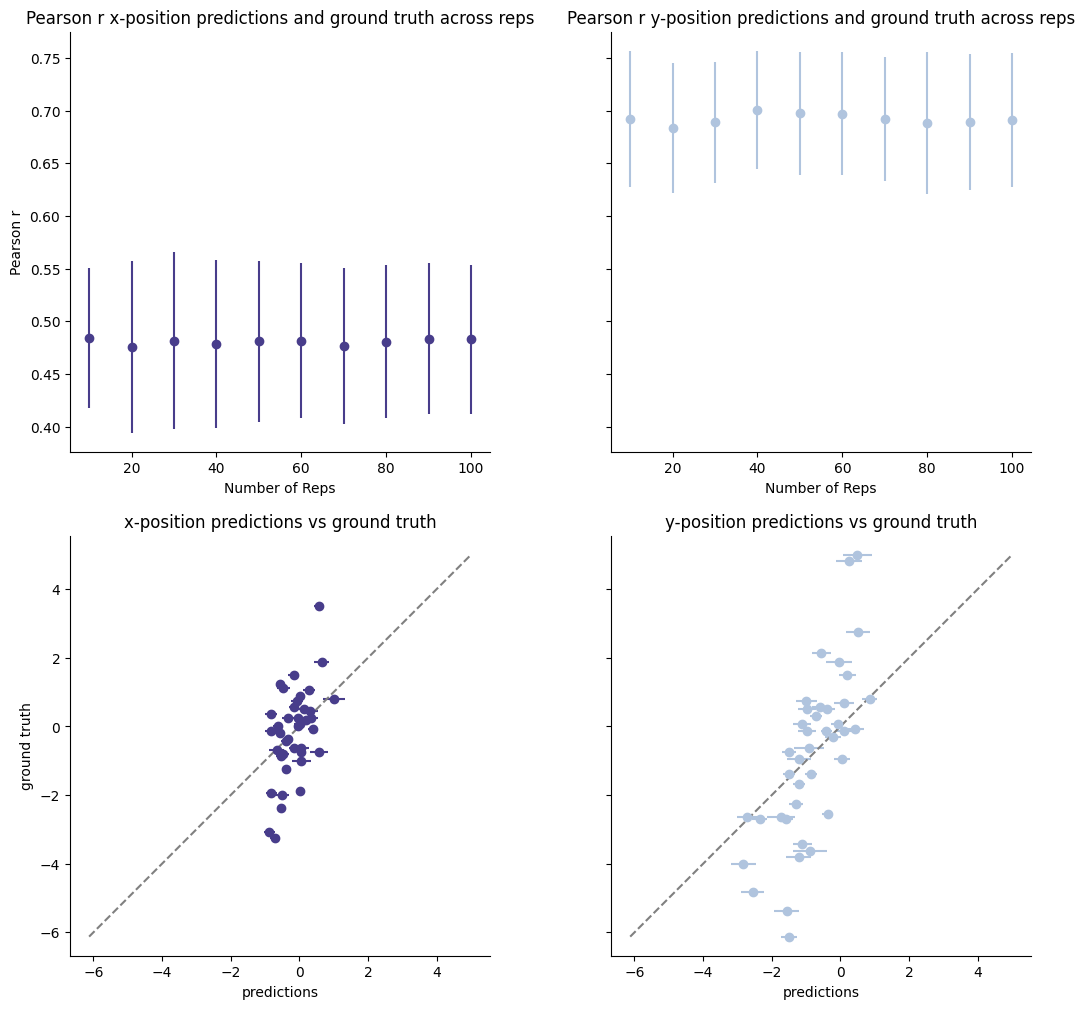

In [31]:
s5_corrs = gt_corrs(s5_xpos,s5_ypos,xpos,ypos)

Final x correlation across all 100 reps: r = 0.4274031837304487 +/- 0.083395668878732
Final y correlation: across all 100 reps: r = 0.6205925207812242 +/- 0.07888279142023609


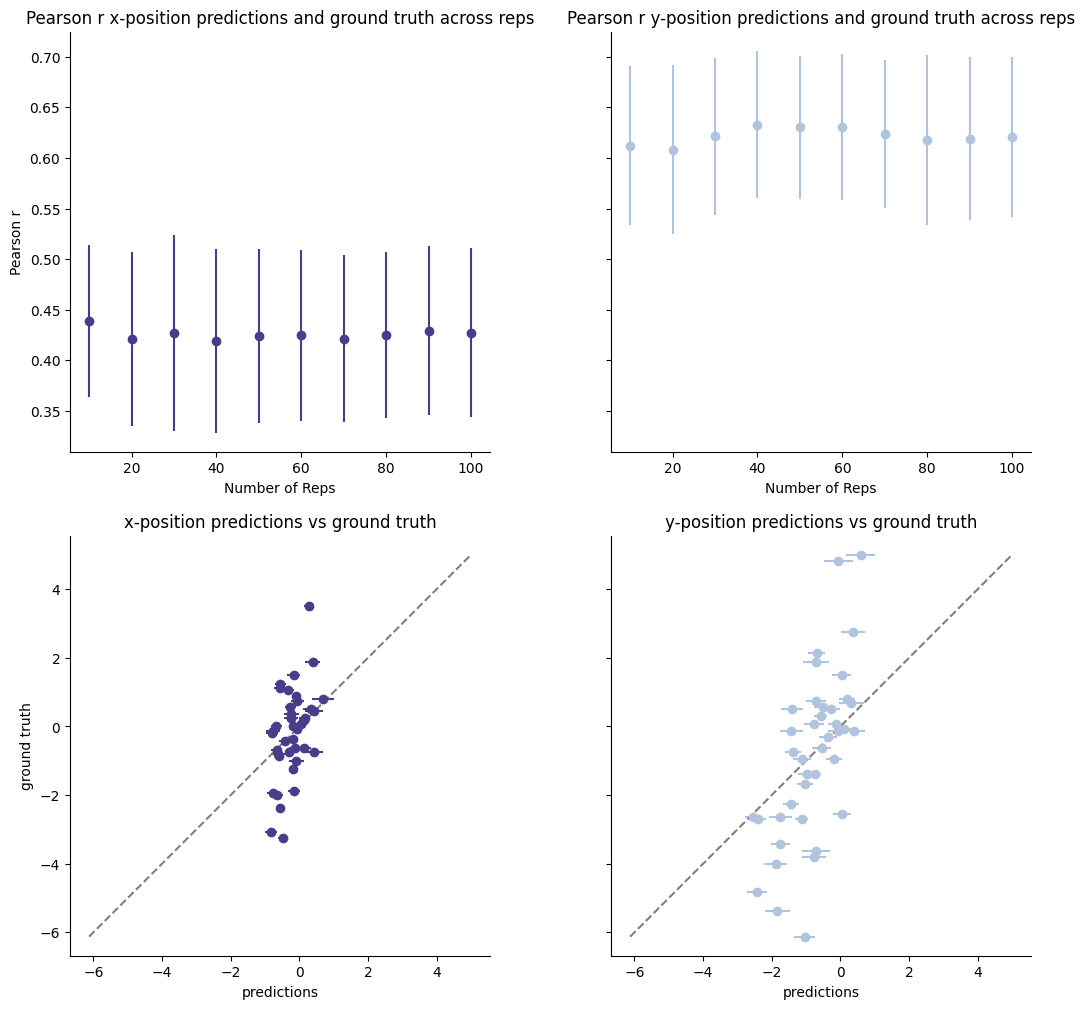

In [32]:
s3_corrs = gt_corrs(s3_xpos,s3_ypos,xpos,ypos)

Final x correlation across all 100 reps: r = 0.42657086423267443 +/- 0.08342233753066965
Final y correlation: across all 100 reps: r = 0.6200070435309339 +/- 0.07936008631749186


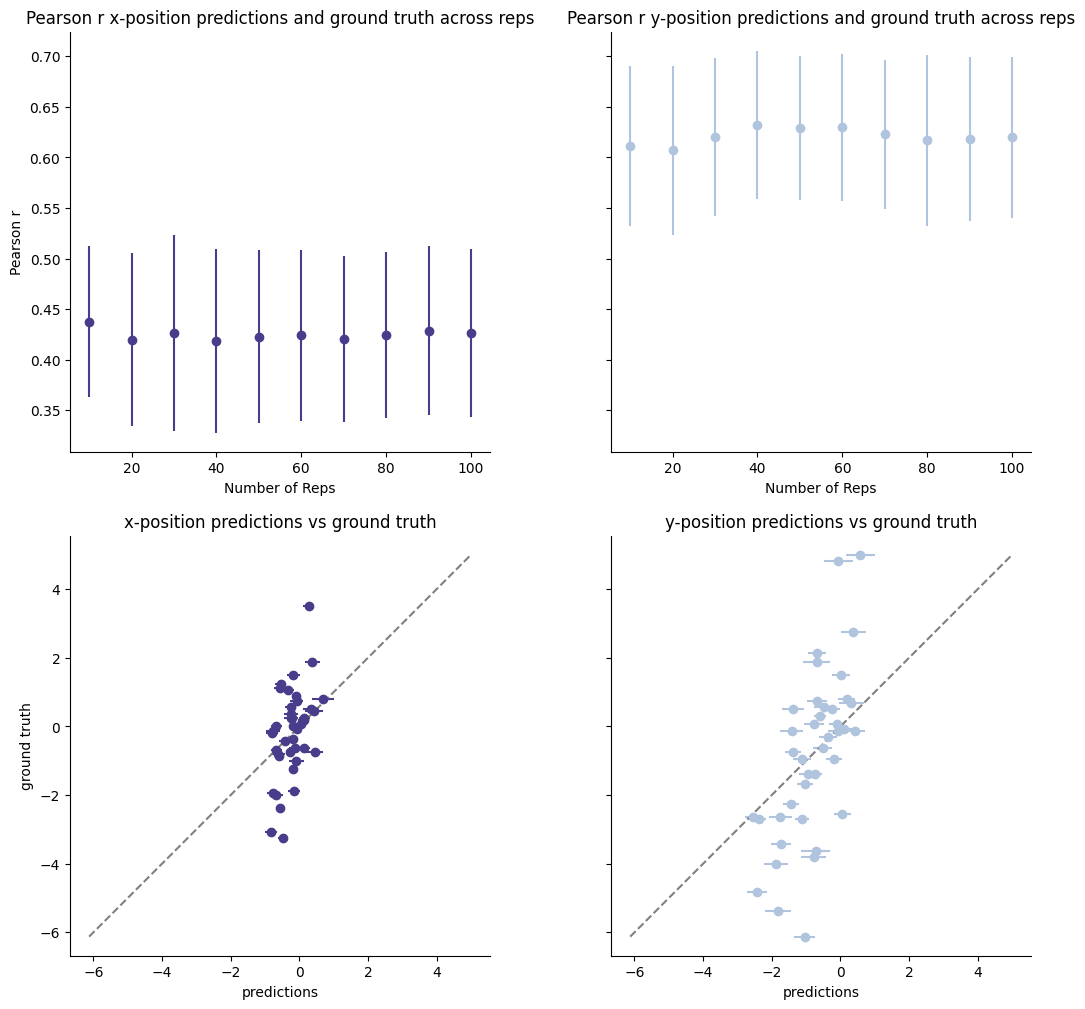

In [33]:
s4_corrs = gt_corrs(s4_xpos,s4_ypos,xpos,ypos)

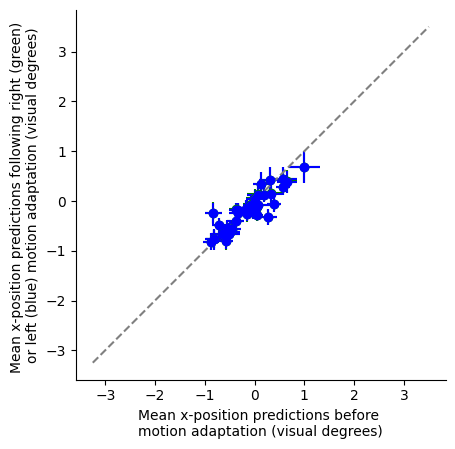

In [34]:
# plot the s3 and s4 xpos predictions against each other 
xpos_range = np.linspace(min(xpos),max(xpos))

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.errorbar(np.nanmean(s5_xpos,axis=1),np.nanmean(s3_xpos,axis=1),xerr=np.nanstd(s5_xpos,axis=1),yerr=np.nanstd(s3_xpos,axis=1),fmt='o',color='green')
plt.errorbar(np.nanmean(s5_xpos,axis=1),np.nanmean(s4_xpos,axis=1),xerr=np.nanstd(s5_xpos,axis=1),yerr=np.nanstd(s4_xpos,axis=1),fmt='o',color='blue')
plt.plot(xpos_range,xpos_range,linestyle='--',color='grey')

plt.xlabel('Mean x-position predictions before \nmotion adaptation (visual degrees)')
plt.ylabel('Mean x-position predictions following right (green) \nor left (blue) motion adaptation (visual degrees)')

x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))
# plt.savefig('/home/eyakub/scratch/convrnnx_s34_scatter.eps', format='eps', bbox_inches='tight')

In [15]:
# save the S4-S3x deltas 
np.save('/home/eyakub/scratch/convrnn_deltax.npy',np.nanmean(s4_xpos,axis=1)-np.nanmean(s3_xpos,axis=1))